Export pre VOSviewer

In [ ]:
import pandas as pd

# ===== INPUT / OUTPUT =====
INPUT_CSV = "/content/wos_merged_deduplicated.csv"
OUTPUT_TXT = "/content/vos_corpus.txt"

# ===== LOAD CSV =====
df = pd.read_csv(INPUT_CSV)
df.columns = df.columns.astype(str).str.strip()

print("Počet článkov:", len(df))
print("Stĺpce v súbore:")
print(df.columns.tolist())

# ===== AUTOMATICKÉ NÁJDENIE STĹPCOV =====
possible_title_cols = ["Article Title", "Title", "Document Title"]
possible_abstract_cols = ["Abstract"]
possible_keywords_cols = ["Author Keywords", "Keywords", "Keywords Plus"]

def find_existing_cols(possible_cols):
    return [col for col in possible_cols if col in df.columns]

title_cols = find_existing_cols(possible_title_cols)
abstract_cols = find_existing_cols(possible_abstract_cols)
keyword_cols = find_existing_cols(possible_keywords_cols)

text_cols = title_cols + abstract_cols + keyword_cols

print("\nPoužité stĺpce:")
print(text_cols)

# ===== CREATE TXT CORPUS =====
with open(OUTPUT_TXT, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        parts = []

        for col in text_cols:
            value = row.get(col, "")
            if pd.notna(value):
                parts.append(str(value))

        text = ". ".join(parts)
        text = text.replace("\n", " ").replace("\r", " ")
        text = " ".join(text.split())

        if text.strip():
            f.write(text + "\n")

print("\nHotovo.")
print("Vytvorený súbor:", OUTPUT_TXT)

Počet článkov: 1864
Stĺpce v súbore:
['Authors', 'Author Full Names', 'Article Title', 'Source Title', 'Publication Year', 'DOI', 'Abstract', 'Author Keywords', 'Keywords Plus', 'Document Type', 'WoS Categories', 'Research Areas', 'ISSN', 'Language', 'IDS Number', 'query_id', 'query_label', 'source_file', 'doi_clean', 'title_clean', 'year_clean', 'authors_clean', 'wos_id_clean', 'dedup_key', 'matched_queries', 'matched_query_labels', 'matched_files', 'duplicate_count']

Použité stĺpce:
['Article Title', 'Abstract', 'Author Keywords', 'Keywords Plus']

Hotovo.
Vytvorený súbor: /content/vos_corpus.txt


Prvotný VOSviewer graf

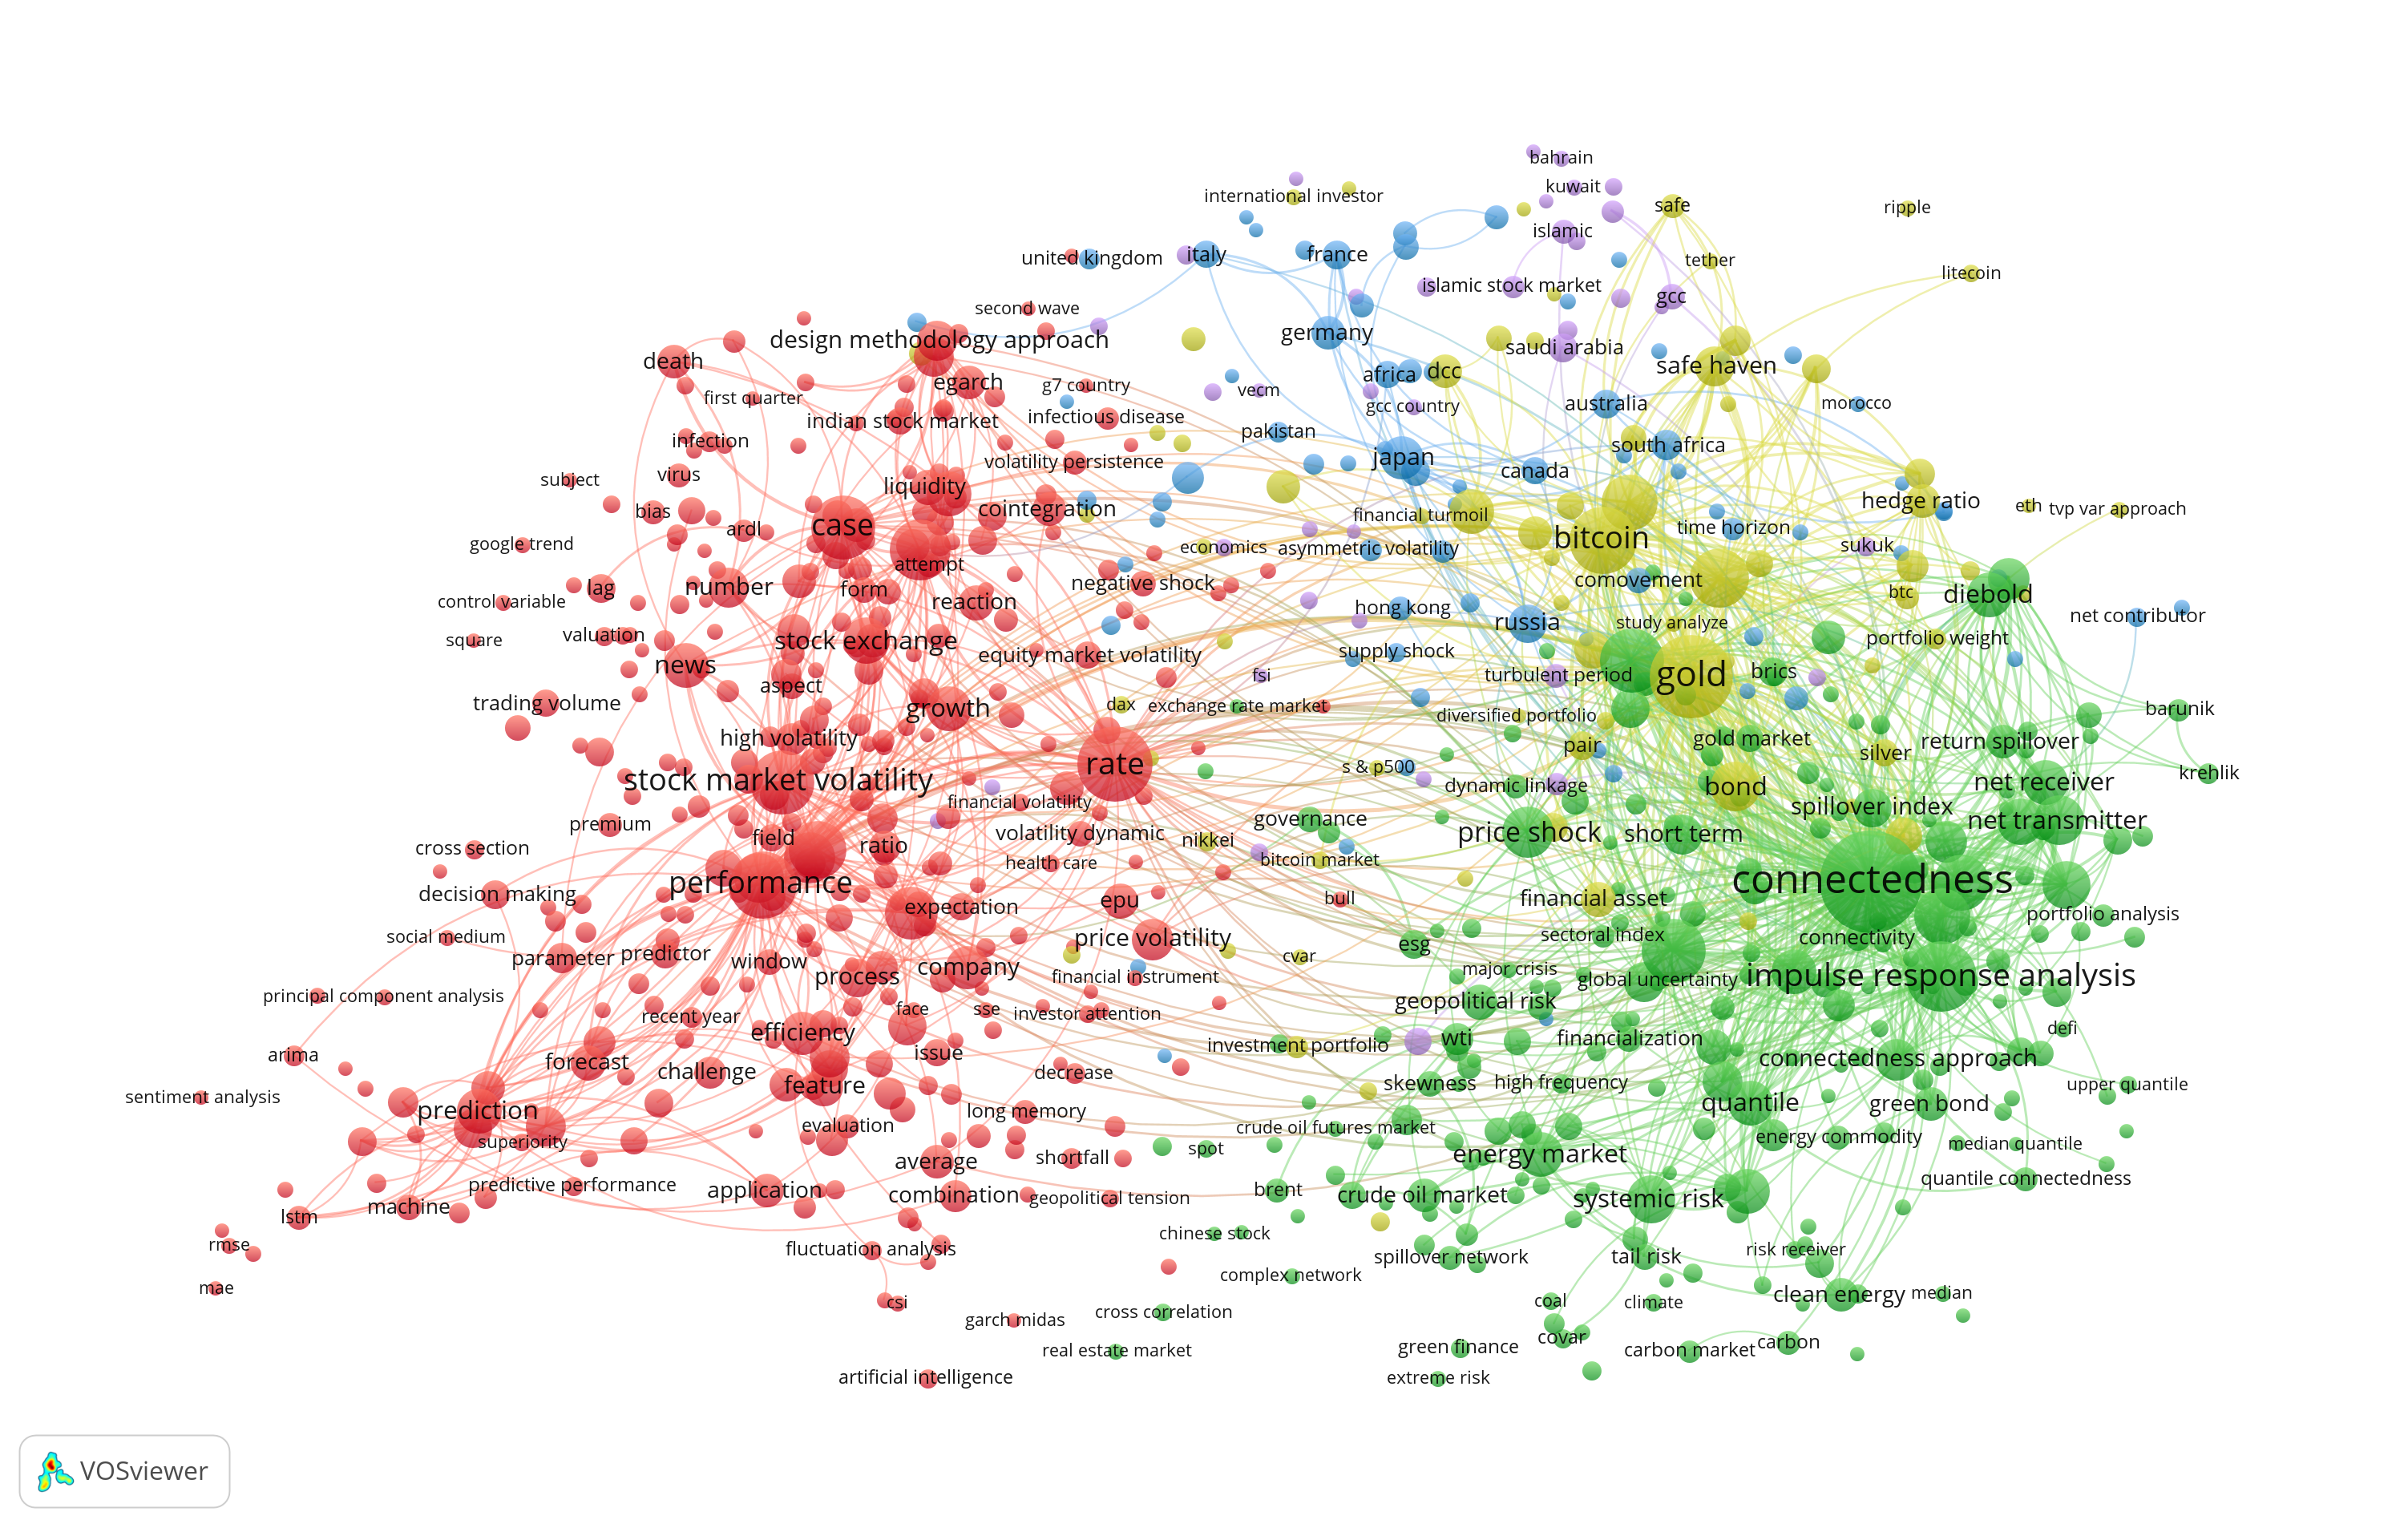

Vidíme, že obsiahnutie je stále príliš široké, obsahuje komodity ako crypto, zlato, striebro, energie, uhlík a ropu. Tie sú irelevantné preto aplikujeme filter na ich odstránenie.

In [ ]:
import re

# =========================
# INPUT / OUTPUT
# =========================

INPUT_FILE = "/content/wos_merged_deduplicated.csv"

OUTPUT_CLEAN = "/content/wos_clean_for_vosviewer.csv"
OUTPUT_REMOVED = "/content/wos_removed_noise.csv"
OUTPUT_TXT = "/content/vos_corpus_clean.txt"

df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.astype(str).str.strip()

print("Loaded records:", len(df))


# =========================
# FIND TEXT COLUMNS
# =========================

possible_text_cols = [
    "Article Title", "Title", "Document Title",
    "Abstract",
    "Author Keywords", "Keywords", "Keywords Plus"
]

text_cols = [c for c in possible_text_cols if c in df.columns]

print("Text columns used:", text_cols)


def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).lower()


df["screening_text"] = ""

for col in text_cols:
    df["screening_text"] += " " + df[col].apply(clean_text)


# =========================
# REQUIRED CORE TOPIC
# =========================

core_market = (
    r"\bstock market\b|\bstock markets\b|"
    r"\bfinancial market\b|\bfinancial markets\b|"
    r"\bequity market\b|\bequity markets\b|"
    r"\bstock exchange\b|\bstock exchanges\b|"
    r"\bstock index\b|\bstock indices\b|"
    r"\bmarket index\b|\bmarket indices\b|"
    r"\bstock return\b|\bstock returns\b|"
    r"\bstock price\b|\bstock prices\b|"
    r"\bs&p\b|\bs&p 500\b|\bsp500\b|\bnasdaq\b|\bdow jones\b|"
    r"\bstoxx\b|\beuro stoxx\b|\bdax\b|\bftse\b|\bcac 40\b|"
    r"\bshanghai composite\b|\bcsi 300\b"
)

core_volatility = (
    r"\bvolatility\b|\bvolatile\b|"
    r"\bhigh volatility\b|\bmarket volatility\b|"
    r"\bstock market volatility\b|"
    r"\bvolatility forecasting\b|\bvolatility prediction\b|"
    r"\brealized volatility\b|\brealised volatility\b|"
    r"\bconditional volatility\b|"
    r"\bvolatility spillover\b|\bvolatility spillovers\b|"
    r"\bvolatility transmission\b"
)

core_covid = (
    r"\bcovid\b|\bcovid-19\b|"
    r"\bcoronavirus\b|\bsars-cov-2\b|"
    r"\bpandemic\b|\bpandemics\b|"
    r"\bpandemic period\b|\bpre-covid\b|\bpost-covid\b"
)

core_method = (
    r"\bgarch\b|\bgjr-garch\b|\begarch\b|\btgarch\b|\bdcc-garch\b|"
    r"\bhar\b|\bhar-rv\b|\bheterogeneous autoregressive\b|"
    r"\bmachine learning\b|\bdeep learning\b|\bartificial intelligence\b|"
    r"\blstm\b|\blong short-term memory\b|"
    r"\bxgboost\b|\brandom forest\b|\bneural network\b|\bneural networks\b|"
    r"\bforecasting\b|\bprediction\b|\bpredictive\b|"
    r"\btime series\b|\bspillover\b|\bspillovers\b|\bconnectedness\b|"
    r"\bimpulse response\b|\bcausality\b|\bco-movement\b|\bco movement\b"
)


# =========================
# NOISE TOPICS TO REMOVE
# =========================

noise_patterns = {
    "crypto": (
        r"\bbitcoin\b|\bbtc\b|\bethereum\b|\beth\b|\bripple\b|\bxrp\b|"
        r"\blitecoin\b|\btether\b|\bcryptocurrency\b|\bcryptocurrencies\b|"
        r"\bcrypto\b|\bblockchain\b|\bdigital currency\b|\bdigital currencies\b"
    ),

    "oil_energy": (
        r"\boil\b|\bcrude oil\b|\bcrude oil market\b|\bbrent\b|\bwti\b|"
        r"\bpetroleum\b|\boil future\b|\boil futures\b|"
        r"\benergy market\b|\benergy markets\b|\benergy price\b|\benergy prices\b|"
        r"\bnatural gas\b|\bgas market\b|\belectricity market\b|"
        r"\bclean energy\b|\brenewable energy\b|\bfossil fuel\b|\bfossil fuels\b"
    ),

    "gold_metals": (
        r"\bgold\b|\bgold market\b|\bsilver\b|\bcopper\b|"
        r"\bprecious metal\b|\bprecious metals\b|\bmetal market\b|\bmetal markets\b"
    ),

    "commodities": (
        r"\bcommodity\b|\bcommodities\b|\bcommodity market\b|\bcommodity markets\b|"
        r"\bcommodity futures\b"
    ),

    "carbon_green_finance": (
        r"\bcarbon market\b|\bcarbon price\b|\bcarbon prices\b|"
        r"\bcarbon emission\b|\bcarbon emissions\b|\bemission allowance\b|"
        r"\bgreen bond\b|\bgreen bonds\b|\bgreen finance\b|"
        r"\bsustainable finance\b"
    ),

    "forex_currency": (
        r"\bforeign exchange\b|\bforex\b|\bexchange rate\b|\bexchange rates\b|"
        r"\bcurrency market\b|\bcurrency markets\b"
    ),

    "bonds_real_estate": (
        r"\bbond market\b|\bbond markets\b|\btreasury bond\b|\bgreen bond\b|"
        r"\breal estate market\b|\bhousing market\b|\bproperty market\b"
    ),

    "health_medical": (
        r"\bhealth care\b|\bhealthcare\b|\binfection\b|\bdisease\b|\bdeath\b|"
        r"\bmortality\b|\bepidemiological\b|\bpublic health\b|\bmedical\b|"
        r"\bvirus\b|\bconfirmed cases\b"
    ),

    "general_noise": (
        r"\bsafe haven\b|\bsafe-haven\b|\bhedge\b|\bhedging\b|"
        r"\brussia-ukraine\b|\brussian-ukraine\b|\bukraine war\b"
    )
}


def has(pattern, text):
    return bool(re.search(pattern, text, flags=re.IGNORECASE))


def get_noise_reasons(text):
    reasons = []
    for label, pattern in noise_patterns.items():
        if has(pattern, text):
            reasons.append(label)
    return "; ".join(reasons)


df["has_market"] = df["screening_text"].apply(lambda x: has(core_market, x))
df["has_volatility"] = df["screening_text"].apply(lambda x: has(core_volatility, x))
df["has_covid"] = df["screening_text"].apply(lambda x: has(core_covid, x))
df["has_method"] = df["screening_text"].apply(lambda x: has(core_method, x))

df["noise_reasons"] = df["screening_text"].apply(get_noise_reasons)
df["has_noise"] = df["noise_reasons"].apply(lambda x: x != "")

# Finálny jeden filter
keep_mask = (
    df["has_market"] &
    df["has_volatility"] &
    df["has_covid"] &
    df["has_method"] &
    ~df["has_noise"]
)

clean = df[keep_mask].copy()
removed = df[~keep_mask].copy()


def removal_reason(row):
    reasons = []

    if not row["has_market"]:
        reasons.append("missing_market")
    if not row["has_volatility"]:
        reasons.append("missing_volatility")
    if not row["has_covid"]:
        reasons.append("missing_covid")
    if not row["has_method"]:
        reasons.append("missing_method")
    if row["has_noise"]:
        reasons.append("noise_topic: " + row["noise_reasons"])

    return "; ".join(reasons)


removed["removal_reason"] = removed.apply(removal_reason, axis=1)

clean.to_csv(OUTPUT_CLEAN, index=False, encoding="utf-8-sig")
removed.to_csv(OUTPUT_REMOVED, index=False, encoding="utf-8-sig")


# =========================
# CREATE TXT FOR VOSVIEWER
# =========================

with open(OUTPUT_TXT, "w", encoding="utf-8") as f:
    for _, row in clean.iterrows():
        parts = []

        for col in text_cols:
            value = row.get(col, "")
            if pd.notna(value):
                parts.append(str(value))

        text = ". ".join(parts)
        text = text.replace("\n", " ").replace("\r", " ")
        text = " ".join(text.split())

        if text.strip():
            f.write(text + "\n")


# =========================
# SUMMARY
# =========================

print("\n======================")
print("FILTER SUMMARY")
print("======================")
print("Original records:", len(df))
print("Kept clean records:", len(clean))
print("Removed records:", len(removed))

print("\nCore matches in original:")
print("Market:", df["has_market"].sum())
print("Volatility:", df["has_volatility"].sum())
print("COVID:", df["has_covid"].sum())
print("Method/context:", df["has_method"].sum())

print("\nNoise topics:")
print(df["noise_reasons"].value_counts().head(20))

print("\nSaved files:")
print(OUTPUT_CLEAN)
print(OUTPUT_REMOVED)
print(OUTPUT_TXT)

Loaded records: 1864
Text columns used: ['Article Title', 'Abstract', 'Author Keywords', 'Keywords Plus']

FILTER SUMMARY
Original records: 1864
Kept clean records: 379
Removed records: 1485

Core matches in original:
Market: 1759
Volatility: 1847
COVID: 1863
Method/context: 1530

Noise topics:
noise_reasons
                                                               552
oil_energy                                                     220
health_medical                                                 114
oil_energy; general_noise                                       68
oil_energy; gold_metals; commodities; general_noise             55
general_noise                                                   54
oil_energy; commodities                                         51
forex_currency                                                  37
crypto; gold_metals; general_noise                              35
crypto                                                          34
oil_energy; gold_met

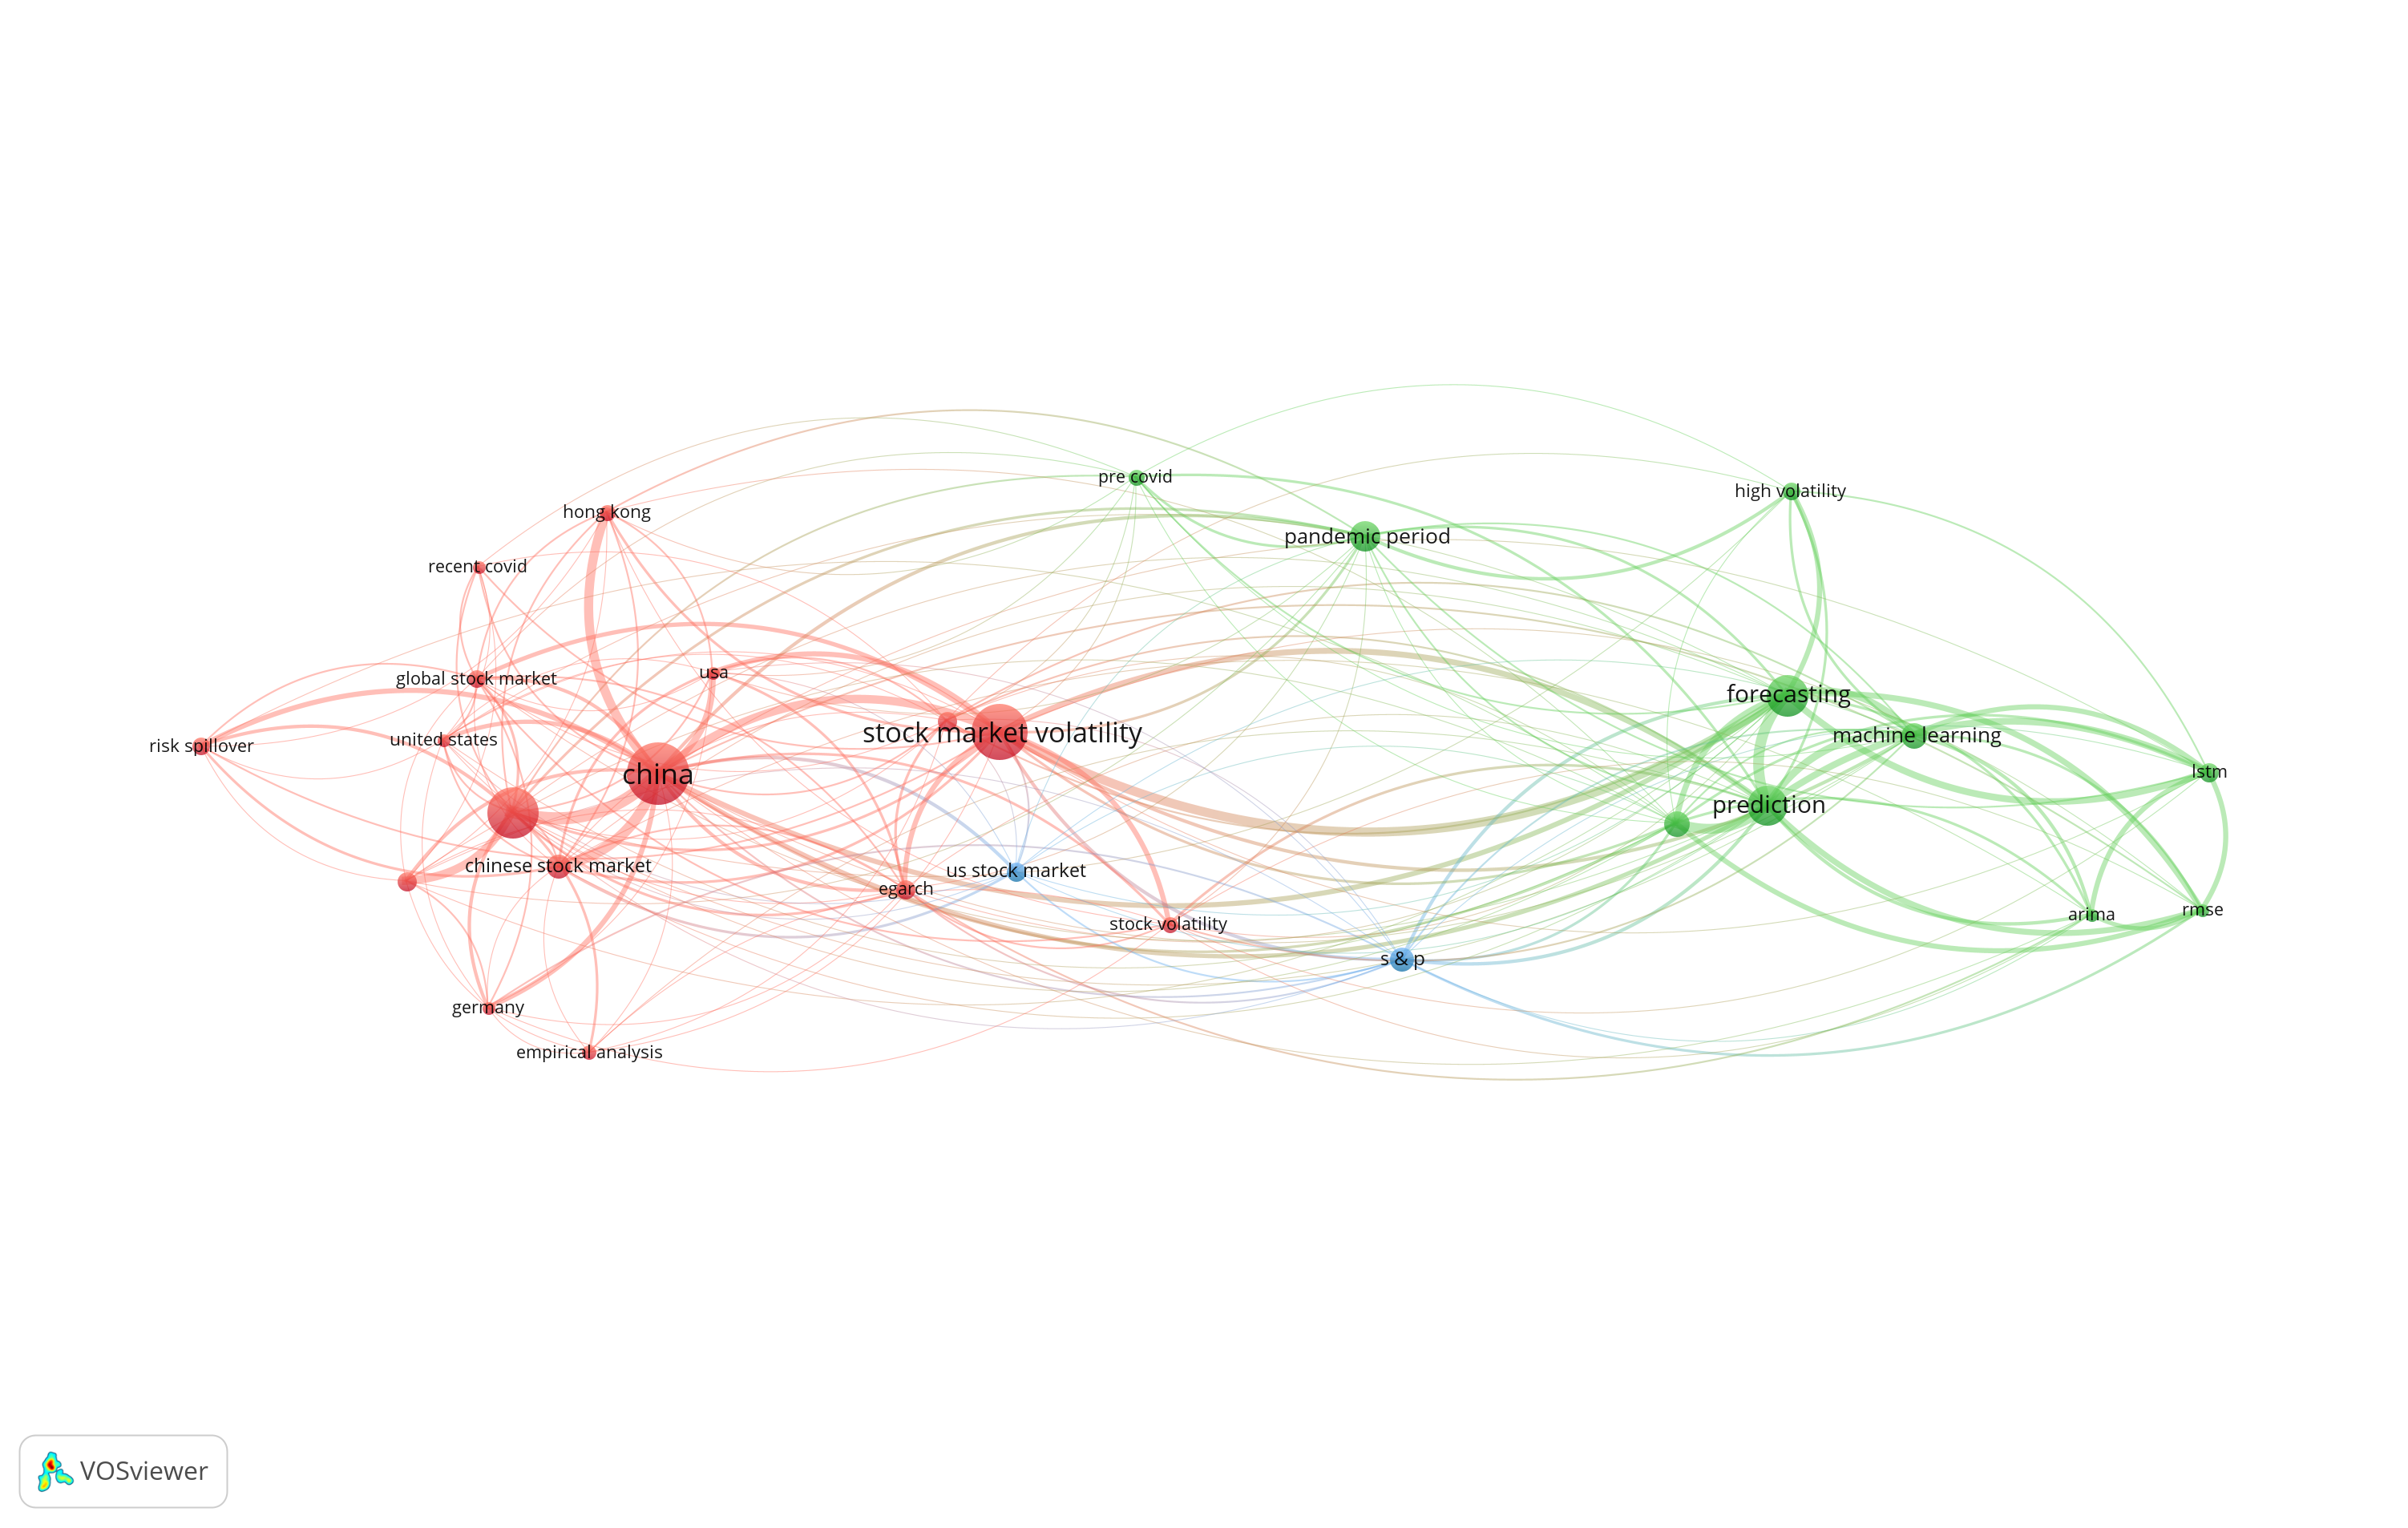

Po filtrovaní máme 379 potenciálne relevantných článkov. Ako je vidieť na grafe VOSviewer, štruktúra článkov zodpovedá tematike výskumu.

Pred manuálnym výberom aplikujeme skript, ktorý priradí každému článku prioritu na základe relevantnosti, čo by malo zjednodušiť manuálny výber.

In [ ]:
# =========================
# INPUT / OUTPUT
# =========================

INPUT_FILE = "/content/wos_clean_for_vosviewer.csv"

OUTPUT_ALL = "/content/wos_screening_readable_all.csv"
OUTPUT_A = "/content/wos_screening_readable_A.csv"
OUTPUT_B = "/content/wos_screening_readable_B.csv"
OUTPUT_C = "/content/wos_screening_readable_C.csv"

df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.astype(str).str.strip()

print("Loaded records:", len(df))


# =========================
# HELPERS
# =========================

def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).lower()

def has(pattern, text):
    return bool(re.search(pattern, text, flags=re.IGNORECASE))

def first_existing(possible_cols):
    for col in possible_cols:
        if col in df.columns:
            return col
    return None

def existing_cols(possible_cols):
    return [c for c in possible_cols if c in df.columns]

def query_contains(series, query_label):
    # zachytí Q1, Q1_general, Q1-general, Q1; Q2 atď.
    pattern = rf"(^|[^A-Z0-9]){query_label}([^0-9]|$)"
    return series.str.contains(pattern, regex=True, na=False)


# =========================
# IDENTIFY COLUMNS
# =========================

title_col = first_existing(["Article Title", "Title", "Document Title"])
abstract_col = first_existing(["Abstract"])
source_col = first_existing(["Source Title", "Source", "Journal", "Publication Name"])
year_col = first_existing(["Publication Year", "Year", "PY"])
doi_col = first_existing(["DOI", "Article DOI"])
authors_col = first_existing(["Author(s)", "Authors", "AU"])
times_cited_col = first_existing(["Times Cited Count", "Times Cited", "TC"])
issn_col = first_existing(["ISSN"])
doc_type_col = first_existing(["Document Type", "DT"])
keywords_col = first_existing(["Author Keywords", "Keywords"])
keywords_plus_col = first_existing(["Keywords Plus"])
wos_cat_col = first_existing(["WoS Categories", "Web of Science Categories"])
research_areas_col = first_existing(["Research Areas"])
wos_id_col = first_existing(["UT", "Accession Number", "WoS ID", "IDS Number"])

title_cols = existing_cols(["Article Title", "Title", "Document Title"])
abstract_cols = existing_cols(["Abstract"])
keyword_cols = existing_cols(["Author Keywords", "Keywords", "Keywords Plus"])

text_cols = title_cols + abstract_cols + keyword_cols

print("Text columns used:", text_cols)


# =========================
# CREATE TEXT FIELDS
# =========================

df["_title_abstract_text"] = ""
for col in title_cols + abstract_cols:
    df["_title_abstract_text"] += " " + df[col].apply(clean_text)

df["_all_text"] = ""
for col in text_cols:
    df["_all_text"] += " " + df[col].apply(clean_text)


# =========================
# QUERY MEMBERSHIP
# =========================

if "matched_queries" in df.columns:
    q = df["matched_queries"].fillna("").astype(str).str.upper()
else:
    q = pd.Series([""] * len(df))

df["_in_Q1"] = query_contains(q, "Q1")
df["_in_Q2"] = query_contains(q, "Q2")
df["_in_Q3"] = query_contains(q, "Q3")
df["_in_Q4"] = query_contains(q, "Q4")

df["_only_Q1"] = (
    df["_in_Q1"] &
    ~df["_in_Q2"] &
    ~df["_in_Q3"] &
    ~df["_in_Q4"]
)


# =========================
# PATTERNS
# =========================

market_pattern = (
    r"\bstock market\w*\b|"
    r"\bfinancial market\w*\b|"
    r"\bequity market\w*\b|"
    r"\bstock index\w*\b|"
    r"\bmarket index\w*\b|"
    r"\bstock exchange\w*\b|"
    r"\bstock return\w*\b|"
    r"\bstock price\w*\b|"
    r"\bs&p\b|\bs&p 500\b|\bsp500\b|"
    r"\bnasdaq\b|\bdow jones\b|"
    r"\bstoxx\b|\beuro stoxx\b|"
    r"\bdax\b|\bftse\b|\bcac 40\b|"
    r"\bshanghai composite\b|\bcsi 300\b"
)

volatility_pattern = (
    r"\bvolatil\w*\b|"
    r"\bvolatility forecasting\b|"
    r"\bvolatility prediction\b|"
    r"\brealized volatility\b|"
    r"\brealised volatility\b|"
    r"\bconditional volatility\b|"
    r"\bvolatility spillover\w*\b|"
    r"\bvolatility transmission\b|"
    r"\bvolatility connectedness\b|"
    r"\bhigh volatility\b|"
    r"\bstock market volatility\b"
)

covid_pattern = (
    r"\bcovid\b|\bcovid-19\b|"
    r"\bcoronavirus\b|"
    r"\bsars-cov-2\b|"
    r"\bpandemic\w*\b|"
    r"\bpandemic period\b|"
    r"\bpre-covid\b|"
    r"\bpost-covid\b"
)

garch_har_pattern = (
    r"\bgarch\b|"
    r"\bgjr-garch\b|"
    r"\begarch\b|"
    r"\btgarch\b|"
    r"\bdcc-garch\b|"
    r"\bhar\b|"
    r"\bhar-rv\b|"
    r"\bheterogeneous autoregressive\b"
)

ai_ml_pattern = (
    r"\bmachine learning\b|"
    r"\bdeep learning\b|"
    r"\bartificial intelligence\b|"
    r"\blstm\b|"
    r"\blong short-term memory\b|"
    r"\bxgboost\b|"
    r"\bneural network\w*\b|"
    r"\brandom forest\b|"
    r"\bsvm\b|"
    r"\bsvr\b|"
    r"\bsupport vector machine\b|"
    r"\bsupport vector regression\b"
)

analytical_pattern = (
    r"\bforecast\w*\b|"
    r"\bpredict\w*\b|"
    r"\bmodel\w*\b|"
    r"\btime series\b|"
    r"\bspillover\w*\b|"
    r"\bconnectedness\b|"
    r"\bempirical analysis\b|"
    r"\btransmission\b|"
    r"\binterdependence\b|"
    r"\bcontagion\b|"
    r"\bgranger causality\b|"
    r"\bimpulse response\b|"
    r"\bdiebold\b|"
    r"\byilmaz\b|"
    r"\btvp-var\b|"
    r"\bvar model\b|"
    r"\bwavelet\b|"
    r"\bcopula\b|"
    r"\barima\b|"
    r"\brmse\b|"
    r"\bmae\b|"
    r"\bqlike\b"
)

target_region_pattern = (
    r"\busa\b|\bu\.s\.\b|\bunited states\b|"
    r"\bus stock market\b|"
    r"\bs&p\b|\bs&p 500\b|\bsp500\b|"
    r"\bnasdaq\b|\bdow jones\b|"
    r"\bchina\b|\bchinese\b|"
    r"\bchinese stock market\b|"
    r"\bshanghai composite\b|\bcsi 300\b|"
    r"\beurope\b|\beuropean\b|"
    r"\beuropean market\b|"
    r"\beuropean stock market\b|"
    r"\beuro area\b|\beurozone\b|"
    r"\bstoxx\b|\beuro stoxx\b|"
    r"\bdax\b|\bftse\b|\bcac 40\b|"
    r"\bglobal stock market\w*\b|"
    r"\bglobal market\w*\b|"
    r"\bdeveloped market\w*\b"
)

noise_pattern = (
    r"\bbitcoin\b|\bbtc\b|"
    r"\bethereum\b|\beth\b|"
    r"\bripple\b|\bxrp\b|"
    r"\blitecoin\b|\btether\b|"
    r"\bcrypto\b|\bcryptocurrency\b|\bcryptocurrencies\b|"
    r"\bblockchain\b|"
    r"\boil\b|\bcrude oil\b|\bbrent\b|\bwti\b|\bpetroleum\b|"
    r"\bgold\b|\bsilver\b|\bcopper\b|"
    r"\bcommodity\b|\bcommodities\b|"
    r"\benergy market\b|\benergy markets\b|"
    r"\bnatural gas\b|\bclean energy\b|\brenewable energy\b|"
    r"\bcarbon market\b|\bcarbon price\b|\bgreen bond\b|"
    r"\bforex\b|\bforeign exchange\b|\bexchange rate\b|\bcurrency market\b|"
    r"\bsafe haven\b|\bsafe-haven\b|"
    r"\bhedge\b|\bhedging\b|"
    r"\bhealthcare\b|\bhealth care\b|\binfection\b|\bdisease\b|\bdeath\b|\bmortality\b"
)


# =========================
# INTERNAL FLAGS
# =========================

df["_ta_market"] = df["_title_abstract_text"].apply(lambda x: has(market_pattern, x))
df["_ta_volatility"] = df["_title_abstract_text"].apply(lambda x: has(volatility_pattern, x))
df["_ta_covid"] = df["_title_abstract_text"].apply(lambda x: has(covid_pattern, x))
df["_ta_garch_har"] = df["_title_abstract_text"].apply(lambda x: has(garch_har_pattern, x))
df["_ta_ai_ml"] = df["_title_abstract_text"].apply(lambda x: has(ai_ml_pattern, x))
df["_ta_analytical"] = df["_title_abstract_text"].apply(lambda x: has(analytical_pattern, x))
df["_ta_target_region"] = df["_title_abstract_text"].apply(lambda x: has(target_region_pattern, x))

df["_all_market"] = df["_all_text"].apply(lambda x: has(market_pattern, x))
df["_all_volatility"] = df["_all_text"].apply(lambda x: has(volatility_pattern, x))
df["_all_covid"] = df["_all_text"].apply(lambda x: has(covid_pattern, x))
df["_all_garch_har"] = df["_all_text"].apply(lambda x: has(garch_har_pattern, x))
df["_all_ai_ml"] = df["_all_text"].apply(lambda x: has(ai_ml_pattern, x))
df["_all_analytical"] = df["_all_text"].apply(lambda x: has(analytical_pattern, x))
df["_all_target_region"] = df["_all_text"].apply(lambda x: has(target_region_pattern, x))
df["_has_noise"] = df["_all_text"].apply(lambda x: has(noise_pattern, x))


# =========================
# INFER QUERY TYPES IF matched_queries MISSING
# =========================

if (q == "").all():
    df["_in_Q1"] = (
        df["_all_market"] &
        df["_all_volatility"] &
        df["_all_covid"] &
        df["_all_analytical"]
    )

    df["_in_Q2"] = (
        df["_all_market"] &
        df["_all_volatility"] &
        df["_all_covid"] &
        df["_all_garch_har"]
    )

    df["_in_Q3"] = (
        df["_all_market"] &
        df["_all_volatility"] &
        df["_all_covid"] &
        df["_all_ai_ml"]
    )

    df["_in_Q4"] = (
        df["_all_market"] &
        df["_all_volatility"] &
        df["_all_covid"] &
        df["_all_garch_har"] &
        df["_all_ai_ml"]
    )

    df["_only_Q1"] = (
        df["_in_Q1"] &
        ~df["_in_Q2"] &
        ~df["_in_Q3"] &
        ~df["_in_Q4"]
    )


# =========================
# PRIORITY SCORE
# =========================

df["priority_score"] = 0

# Title / abstract = silnejší dôkaz
df.loc[df["_ta_market"], "priority_score"] += 3
df.loc[df["_ta_volatility"], "priority_score"] += 3
df.loc[df["_ta_covid"], "priority_score"] += 3
df.loc[df["_ta_garch_har"], "priority_score"] += 4
df.loc[df["_ta_ai_ml"], "priority_score"] += 4
df.loc[df["_ta_analytical"], "priority_score"] += 2
df.loc[df["_ta_target_region"], "priority_score"] += 3

# Keywords / all text = slabší dôkaz
df.loc[df["_all_market"] & ~df["_ta_market"], "priority_score"] += 1
df.loc[df["_all_volatility"] & ~df["_ta_volatility"], "priority_score"] += 1
df.loc[df["_all_covid"] & ~df["_ta_covid"], "priority_score"] += 1
df.loc[df["_all_garch_har"] & ~df["_ta_garch_har"], "priority_score"] += 2
df.loc[df["_all_ai_ml"] & ~df["_ta_ai_ml"], "priority_score"] += 2
df.loc[df["_all_analytical"] & ~df["_ta_analytical"], "priority_score"] += 1
df.loc[df["_all_target_region"] & ~df["_ta_target_region"], "priority_score"] += 1

# Query-based priority
df.loc[df["_in_Q4"], "priority_score"] += 6
df.loc[df["_in_Q2"], "priority_score"] += 3
df.loc[df["_in_Q3"], "priority_score"] += 3
df.loc[df["_only_Q1"], "priority_score"] -= 1

# Hybrid bonus
df.loc[df["_all_garch_har"] & df["_all_ai_ml"], "priority_score"] += 3

# Noise penalty
df.loc[df["_has_noise"], "priority_score"] -= 7


# =========================
# PRIORITY GROUPS
# =========================

df["_has_core_topic"] = (
    df["_all_market"] &
    df["_all_volatility"] &
    df["_all_covid"] &
    (df["_all_garch_har"] | df["_all_ai_ml"] | df["_all_analytical"])
)

df["_has_specific_method"] = (
    df["_all_garch_har"] | df["_all_ai_ml"]
)

A_mask = (
    df["_has_core_topic"] &
    ~df["_has_noise"] &
    (
        df["_in_Q4"] |
        (df["_in_Q2"] & df["_in_Q3"]) |
        (df["_has_specific_method"] & df["_all_target_region"] & (df["priority_score"] >= 16))
    )
)

B_mask = (
    ~A_mask &
    df["_has_core_topic"] &
    ~df["_has_noise"] &
    (
        df["_in_Q2"] |
        df["_in_Q3"] |
        (df["_all_target_region"] & df["priority_score"] >= 12)
    )
)

df["priority_group"] = "C_low_priority"
df.loc[B_mask, "priority_group"] = "B_backup"
df.loc[A_mask, "priority_group"] = "A_screen_first"


# =========================
# READABLE EXPLANATION COLUMNS
# =========================

def make_query_group(row):
    qs = []
    if row["_in_Q1"]:
        qs.append("Q1 analytical/modeling")
    if row["_in_Q2"]:
        qs.append("Q2 GARCH/HAR")
    if row["_in_Q3"]:
        qs.append("Q3 AI/ML/DL")
    if row["_in_Q4"]:
        qs.append("Q4 hybrid")
    return "; ".join(qs) if qs else "not identified"

def make_method_focus(row):
    methods = []
    if row["_all_garch_har"]:
        methods.append("econometric: GARCH/HAR")
    if row["_all_ai_ml"]:
        methods.append("AI/ML/DL")
    if row["_all_analytical"]:
        methods.append("analytical/modeling context")
    return "; ".join(methods) if methods else "unclear"

def make_screening_rationale(row):
    reasons = []

    if row["_all_market"]:
        reasons.append("market")
    if row["_all_volatility"]:
        reasons.append("volatility")
    if row["_all_covid"]:
        reasons.append("COVID")
    if row["_all_garch_har"]:
        reasons.append("GARCH/HAR")
    if row["_all_ai_ml"]:
        reasons.append("AI/ML/DL")
    if row["_all_analytical"]:
        reasons.append("analytical/modeling")
    if row["_all_target_region"]:
        reasons.append("target region")
    if row["_has_noise"]:
        reasons.append("possible noise topic")

    return "; ".join(reasons)

df["query_group"] = df.apply(make_query_group, axis=1)
df["method_focus"] = df.apply(make_method_focus, axis=1)
df["screening_rationale"] = df.apply(make_screening_rationale, axis=1)

df["manual_decision"] = ""
df["exclusion_reason"] = ""
df["screening_notes"] = ""


# =========================
# CREATE READABLE OUTPUT
# =========================

wanted_cols = [
    "priority_group",
    "priority_score",
    "manual_decision",
    "exclusion_reason",
    "screening_notes",
    "matched_queries",
    "query_group",
    "method_focus",
    "screening_rationale",

    title_col,
    abstract_col,
    keywords_col,
    keywords_plus_col,

    authors_col,
    source_col,
    year_col,
    doi_col,
    times_cited_col,
    issn_col,
    doc_type_col,
    wos_cat_col,
    research_areas_col,
    wos_id_col
]

wanted_cols = [c for c in wanted_cols if c is not None and c in df.columns]
wanted_cols = list(dict.fromkeys(wanted_cols))

screen = df[wanted_cols].copy()


# =========================
# RENAME COLUMNS
# =========================

rename_map = {}

if title_col:
    rename_map[title_col] = "title"
if abstract_col:
    rename_map[abstract_col] = "abstract"
if keywords_col:
    rename_map[keywords_col] = "author_keywords"
if keywords_plus_col:
    rename_map[keywords_plus_col] = "keywords_plus"
if authors_col:
    rename_map[authors_col] = "authors"
if source_col:
    rename_map[source_col] = "source_title"
if year_col:
    rename_map[year_col] = "publication_year"
if doi_col:
    rename_map[doi_col] = "doi"
if times_cited_col:
    rename_map[times_cited_col] = "times_cited"
if issn_col:
    rename_map[issn_col] = "issn"
if doc_type_col:
    rename_map[doc_type_col] = "document_type"
if wos_cat_col:
    rename_map[wos_cat_col] = "wos_categories"
if research_areas_col:
    rename_map[research_areas_col] = "research_areas"
if wos_id_col:
    rename_map[wos_id_col] = "wos_identifier"

screen = screen.rename(columns=rename_map)


# =========================
# FINAL COLUMN ORDER
# =========================

final_order = [
    "priority_group",
    "priority_score",
    "manual_decision",
    "exclusion_reason",
    "screening_notes",
    "matched_queries",
    "query_group",
    "method_focus",
    "screening_rationale",

    "title",
    "abstract",
    "author_keywords",
    "keywords_plus",

    "authors",
    "source_title",
    "publication_year",
    "doi",
    "times_cited",
    "issn",
    "document_type",
    "wos_categories",
    "research_areas",
    "wos_identifier"
]

final_order = [c for c in final_order if c in screen.columns]
screen = screen[final_order].fillna("")


# =========================
# SORT
# =========================

group_order = {
    "A_screen_first": 1,
    "B_backup": 2,
    "C_low_priority": 3
}

screen["_group_order"] = screen["priority_group"].map(group_order)

screen = screen.sort_values(
    by=["_group_order", "priority_score"],
    ascending=[True, False]
).drop(columns=["_group_order"])


# =========================
# SAVE READABLE CSV FILES
# =========================
# sep=";" je vhodnejšie pre slovenský Excel

screen.to_csv(OUTPUT_ALL, index=False, encoding="utf-8-sig", sep=";")

screen[screen["priority_group"] == "A_screen_first"].to_csv(
    OUTPUT_A, index=False, encoding="utf-8-sig", sep=";"
)

screen[screen["priority_group"] == "B_backup"].to_csv(
    OUTPUT_B, index=False, encoding="utf-8-sig", sep=";"
)

screen[screen["priority_group"] == "C_low_priority"].to_csv(
    OUTPUT_C, index=False, encoding="utf-8-sig", sep=";"
)


# =========================
# SUMMARY
# =========================

print("\n====================")
print("SCREENING SUMMARY")
print("====================")
print("Total records:", len(screen))
print("A - screen first:", (screen["priority_group"] == "A_screen_first").sum())
print("B - backup:", (screen["priority_group"] == "B_backup").sum())
print("C - low priority:", (screen["priority_group"] == "C_low_priority").sum())

print("\nSaved files:")
print(OUTPUT_ALL)
print(OUTPUT_A)
print(OUTPUT_B)
print(OUTPUT_C)

Loaded records: 379
Text columns used: ['Article Title', 'Abstract', 'Author Keywords', 'Keywords Plus']


/tmp/ipykernel_1973/1465195220.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, regex=True, na=False)
/tmp/ipykernel_1973/1465195220.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, regex=True, na=False)
/tmp/ipykernel_1973/1465195220.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, regex=True, na=False)
/tmp/ipykernel_1973/1465195220.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, regex=True, na=False)



SCREENING SUMMARY
Total records: 379
A - screen first: 87
B - backup: 118
C - low priority: 174

Saved files:
/content/wos_screening_readable_all.csv
/content/wos_screening_readable_A.csv
/content/wos_screening_readable_B.csv
/content/wos_screening_readable_C.csv


Na 379 článkoch prebehol manuálny screening cez kľúčové slová, abstrakt a názov.

In [ ]:
import pandas as pd
import os

# =========================
# INPUT FILES
# =========================

files = [
    "/content/wos_screening_readable_A_screened.csv",
    "/content/wos_screening_readable_B_screened.csv",
    "/content/wos_screening_readable_C_screened.csv"
]

# =========================
# OUTPUT FILES
# =========================

OUTPUT_ALL = "/content/wos_screening_merged_all_decisions.csv"
OUTPUT_INCLUDE = "/content/wos_final_include.csv"
OUTPUT_MAYBE = "/content/wos_final_maybe.csv"
OUTPUT_EXCLUDE = "/content/wos_final_exclude.csv"
OUTPUT_UNCLASSIFIED = "/content/wos_unclassified_decisions.csv"


# =========================
# ROBUST CSV READER
# =========================

def read_csv_robust(path):
    encodings = ["utf-8-sig", "utf-8", "cp1250", "windows-1250", "latin1"]
    separators = [";", ",", "\t"]

    for enc in encodings:
        for sep in separators:
            try:
                df = pd.read_csv(
                    path,
                    sep=sep,
                    encoding=enc,
                    dtype=str,
                    engine="python",
                    on_bad_lines="skip"
                )

                # úspešné čítanie = viac ako 1 stĺpec
                if df.shape[1] > 1:
                    print(f"Loaded {os.path.basename(path)} | encoding={enc} | sep='{sep}' | rows={len(df)}")
                    return df

            except UnicodeDecodeError:
                continue
            except Exception:
                continue

    raise ValueError(f"Could not read file: {path}")


# =========================
# LOAD FILES
# =========================

dfs = []

for file in files:
    if not os.path.exists(file):
        print(f"Missing file: {file}")
        continue

    df = read_csv_robust(file)
    df.columns = df.columns.astype(str).str.strip()
    df["source_screening_file"] = os.path.basename(file)

    dfs.append(df)

if len(dfs) == 0:
    raise ValueError("No files were loaded.")

merged = pd.concat(dfs, ignore_index=True)

print("\nMerged records:", len(merged))
print("Columns:")
print(merged.columns.tolist())


# =========================
# CHECK MANUAL DECISION COLUMN
# =========================

if "manual_decision" not in merged.columns:
    raise ValueError("Column 'manual_decision' was not found. Check the column name in your CSV files.")


# =========================
# NORMALIZE DECISIONS
# =========================

def normalize_decision(x):
    if pd.isna(x):
        return ""

    x = str(x).strip().lower()
    x = x.replace(".", "").replace(",", "").replace(";", "")
    x = " ".join(x.split())

    if x in ["include", "included", "yes", "y", "ano", "áno", "a"]:
        return "include"

    if x in ["maybe", "unclear", "check", "manual check", "m", "mozno", "možno"]:
        return "maybe"

    if x in ["exclude", "excluded", "no", "n", "nie", "e"]:
        return "exclude"

    return x

merged["manual_decision_clean"] = merged["manual_decision"].apply(normalize_decision)


# =========================
# SPLIT DATA
# =========================

include_df = merged[merged["manual_decision_clean"] == "include"].copy()
maybe_df = merged[merged["manual_decision_clean"] == "maybe"].copy()
exclude_df = merged[merged["manual_decision_clean"] == "exclude"].copy()

unclassified_df = merged[
    ~merged["manual_decision_clean"].isin(["include", "maybe", "exclude"])
].copy()


# =========================
# DEDUPLICATION
# =========================

def deduplicate(df):
    df = df.copy()

    if "doi" in df.columns:
        df["_doi_norm"] = df["doi"].fillna("").astype(str).str.lower().str.strip()
    else:
        df["_doi_norm"] = ""

    if "title" in df.columns:
        df["_title_norm"] = df["title"].fillna("").astype(str).str.lower().str.strip()
    else:
        df["_title_norm"] = ""

    with_doi = df[df["_doi_norm"] != ""].drop_duplicates(subset=["_doi_norm"], keep="first")
    without_doi = df[df["_doi_norm"] == ""].drop_duplicates(subset=["_title_norm"], keep="first")

    out = pd.concat([with_doi, without_doi], ignore_index=True)
    out = out.drop(columns=[c for c in ["_doi_norm", "_title_norm"] if c in out.columns])

    return out

include_df = deduplicate(include_df)
maybe_df = deduplicate(maybe_df)
exclude_df = deduplicate(exclude_df)


# =========================
# SAVE FILES
# =========================

merged.to_csv(OUTPUT_ALL, index=False, encoding="utf-8-sig", sep=";")
include_df.to_csv(OUTPUT_INCLUDE, index=False, encoding="utf-8-sig", sep=";")
maybe_df.to_csv(OUTPUT_MAYBE, index=False, encoding="utf-8-sig", sep=";")
exclude_df.to_csv(OUTPUT_EXCLUDE, index=False, encoding="utf-8-sig", sep=";")
unclassified_df.to_csv(OUTPUT_UNCLASSIFIED, index=False, encoding="utf-8-sig", sep=";")


# =========================
# SUMMARY
# =========================

print("\n======================")
print("SCREENING SPLIT SUMMARY")
print("======================")
print("All merged records:", len(merged))
print("Include:", len(include_df))
print("Maybe:", len(maybe_df))
print("Exclude:", len(exclude_df))
print("Unclassified / empty decision:", len(unclassified_df))

print("\nDecision values found:")
print(merged["manual_decision_clean"].value_counts(dropna=False))

print("\nSaved files:")
print(OUTPUT_ALL)
print(OUTPUT_INCLUDE)
print(OUTPUT_MAYBE)
print(OUTPUT_EXCLUDE)
print(OUTPUT_UNCLASSIFIED)

if len(unclassified_df) > 0:
    print("\nUnclassified examples:")
    cols = [c for c in ["manual_decision", "manual_decision_clean", "title"] if c in unclassified_df.columns]
    display(unclassified_df[cols].head(20))

Loaded wos_screening_readable_A_screened.csv | encoding=cp1250 | sep='	' | rows=87
Loaded wos_screening_readable_B_screened.csv | encoding=cp1250 | sep='	' | rows=118
Loaded wos_screening_readable_C_screened.csv | encoding=cp1250 | sep='	' | rows=174

Merged records: 379
Columns:
['priority_group', 'priority_score', 'manual_decision', 'exclusion_reason', 'screening_notes', 'matched_queries', 'query_group', 'method_focus', 'screening_rationale', 'title', 'abstract', 'author_keywords', 'keywords_plus', 'authors', 'source_title', 'publication_year', 'doi', 'issn', 'document_type', 'wos_categories', 'research_areas', 'wos_identifier', 'source_screening_file']

SCREENING SPLIT SUMMARY
All merged records: 379
Include: 52
Maybe: 31
Exclude: 296
Unclassified / empty decision: 0

Decision values found:
manual_decision_clean
exclude    296
include     52
maybe       31
Name: count, dtype: int64

Saved files:
/content/wos_screening_merged_all_decisions.csv
/content/wos_final_include.csv
/content/

Posledný krok zahŕňa opakovaný manuálny výber pre finálny set článkov.

In [10]:
import pandas as pd
import os

# =========================
# INPUT FILES
# =========================

INPUT_FILES = [
    "/content/wos_final_include_screened.csv",
    "/content/wos_final_maybe_screened.csv"
]

OUTPUT_FILE = "/content/final_include_articles_clean.csv"


# =========================
# LOAD CSV
# =========================

def read_csv_robust(path):
    encodings = ["utf-8-sig", "utf-8", "cp1250", "windows-1250", "latin1"]

    for enc in encodings:
        try:
            df = pd.read_csv(
                path,
                sep=None,
                engine="python",
                encoding=enc,
                dtype=str,
                keep_default_na=False
            )
            print(f"Loaded {os.path.basename(path)} | rows={len(df)} | encoding={enc}")
            return df
        except Exception:
            continue

    raise ValueError(f"Could not read file: {path}")


dfs = []

for path in INPUT_FILES:
    if os.path.exists(path):
        df = read_csv_robust(path)
        df.columns = df.columns.astype(str).str.strip()
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
    else:
        print("Missing:", path)

if not dfs:
    raise ValueError("No files loaded.")

merged = pd.concat(dfs, ignore_index=True)

print("\nMerged rows:", len(merged))
print("Columns:")
print(merged.columns.tolist())


# =========================
# KEEP ONLY INCLUDE
# =========================

if "manual_decision" not in merged.columns:
    raise ValueError("Column 'manual_decision' not found.")

def normalize_decision(x):
    x = str(x).strip().lower()
    x = x.replace(".", "").replace(",", "").replace(";", "")
    x = " ".join(x.split())

    if x in ["include", "included", "yes", "y", "ano", "áno", "a"]:
        return "include"
    if x in ["maybe", "m", "mozno", "možno"]:
        return "maybe"
    if x in ["exclude", "excluded", "no", "n", "nie", "e"]:
        return "exclude"

    return x

merged["decision_final"] = merged["manual_decision"].apply(normalize_decision)

print("\nDecision values:")
print(merged["decision_final"].value_counts(dropna=False))

include_df = merged[merged["decision_final"] == "include"].copy()

# =========================
# KEEP ONLY USEFUL COLUMNS
# =========================

wanted_cols = [
    "manual_decision",

    "matched_queries",
    "query_group",
    "method_focus",
    "screening_rationale",

    "title",
    "abstract",
    "author_keywords",
    "keywords_plus",

    "authors",
    "source_title",
    "publication_year",
    "doi",
    "times_cited",
    "issn",
    "document_type",
    "wos_categories",
    "research_areas",
    "wos_identifier"
]

wanted_cols = [c for c in wanted_cols if c in include_df.columns]

clean = include_df[wanted_cols].copy()


# =========================
# REMOVE EMPTY COLUMNS
# =========================

clean = clean.loc[:, ~(clean.astype(str).apply(lambda col: col.str.strip().eq("").all()))]

# =========================
# SAVE
# =========================

clean.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)

print("\nSaved:", OUTPUT_FILE)
print("Final rows:", len(clean))
print("Final columns:")
print(clean.columns.tolist())

display(clean.head(10))

Loaded wos_final_include_screened.csv | rows=52 | encoding=cp1250
Loaded wos_final_maybe_screened.csv | rows=31 | encoding=cp1250

Merged rows: 83
Columns:
['priority_group', 'priority_score', 'manual_decision', 'exclusion_reason', 'screening_notes', 'matched_queries', 'query_group', 'method_focus', 'screening_rationale', 'title', 'abstract', 'author_keywords', 'keywords_plus', 'authors', 'source_title', 'publication_year', 'doi', 'issn', 'document_type', 'wos_categories', 'research_areas', 'wos_identifier', 'source_screening_file', 'manual_decision_clean', 'source_file']

Decision values:
decision_final
exclude    49
include    31
maybe       3
Name: count, dtype: int64

Saved: /content/final_include_articles_clean.csv
Final rows: 31
Final columns:
['manual_decision', 'matched_queries', 'query_group', 'method_focus', 'screening_rationale', 'title', 'abstract', 'author_keywords', 'keywords_plus', 'authors', 'source_title', 'publication_year', 'doi', 'issn', 'document_type', 'wos_catego

,manual_decision,matched_queries,query_group,method_focus,screening_rationale,title,abstract,author_keywords,keywords_plus,authors,source_title,publication_year,doi,issn,document_type,wos_categories,research_areas,wos_identifier
0,include,Q1; Q2; Q3; Q4,Q1 analytical/modeling; Q2 GARCH/HAR; Q3 AI/ML...,econometric: GARCH/HAR; AI/ML/DL; analytical/m...,market; volatility; COVID; GARCH/HAR; AI/ML/DL...,Stock market forecasting accuracy of asymmetri...,We propose a new clustering approach for compa...,Cluster analysis; COVID-19; Forecast accuracy;...,TIME-SERIES,"Caiado, J; Lúcio, F",NORTH AMERICAN JOURNAL OF ECONOMICS AND FINANCE,2023,10.1016/j.najef.2023.101971,1062-9408,Article,"Business, Finance; Economics",Business & Economics,T0DR4
1,include,Q1; Q2; Q3; Q4,Q1 analytical/modeling; Q2 GARCH/HAR; Q3 AI/ML...,econometric: GARCH/HAR; AI/ML/DL; analytical/m...,market; volatility; COVID; GARCH/HAR; AI/ML/DL...,COVID-19 and Stock Market Volatility: A Cluste...,We study how the COVID-19 pandemic affected so...,Autocorrelation; Cluster analysis; COVID-19; T...,TIME-SERIES,"Lucio, F; Caiado, J",FINANCE RESEARCH LETTERS,2022,10.1016/j.frl.2022.103141,1544-6123,Article,"Business, Finance",Business & Economics,3G9IE
3,include,Q1; Q2,Q1 analytical/modeling; Q2 GARCH/HAR,econometric: GARCH/HAR; analytical/modeling co...,market; volatility; COVID; GARCH/HAR; analytic...,Co-movement dynamics of US and Chinese stock m...,This paper aims to examine the co-movement bet...,China; COVID-19; co-movement; stock; EGARCH; v...,,"Song, G; Xia, ZQ; Basheer, MF; Shah, SMA",ECONOMIC RESEARCH-EKONOMSKA ISTRAZIVANJA,2022,10.1080/1331677X.2021.1957971,1331-677X,Article,Economics,Business & Economics,3N9IP
6,include,Q1; Q3,Q1 analytical/modeling; Q3 AI/ML/DL,AI/ML/DL; analytical/modeling context,market; volatility; COVID; AI/ML/DL; analytica...,Can hybrid model improve the forecasting perfo...,The sudden eruption of COVID-19 has inflicted ...,Stock price index multi-step forecasting; COVI...,VOLATILITY; DECOMPOSITION; PREDICTION,"Yang, Q; Yu, YY; Dai, DS; He, Q; Lin, Y",NORTH AMERICAN JOURNAL OF ECONOMICS AND FINANCE,2024,10.1016/j.najef.2024.102252,1062-9408,Article,"Business, Finance; Economics",Business & Economics,C7I4P
7,include,Q1; Q3,Q1 analytical/modeling; Q3 AI/ML/DL,AI/ML/DL; analytical/modeling context,market; volatility; COVID; AI/ML/DL; analytica...,Cross-Market Bankruptcy Prediction: An Interpr...,The increasing complexity and interconnectedne...,Cross-Market Bankruptcy Prediction; Ensemble L...,FINANCIAL RATIOS; CORPORATE BANKRUPTCY; MODELS...,"Hussain, AB; Jingchun, S; Hussain, B; Shaique,...",COMPUTATIONAL ECONOMICS,2026,10.1007/s10614-025-11266-8,0927-7099,Article; Early Access,"Economics; Management; Mathematics, Interdisci...",Business & Economics; Mathematics,DQ6SA
10,include,Q1; Q3,Q1 analytical/modeling; Q3 AI/ML/DL,AI/ML/DL; analytical/modeling context,market; volatility; COVID; AI/ML/DL; analytica...,Multifractal Behaviors of Stock Indices and Th...,"The financial market is a complex system, whic...",multifractal; forecasting; OSW-MF-DFA; GRU neu...,MARKET-EFFICIENCY; LONG MEMORY; CHINESE,"Zhang, SW; Fang, W",ENTROPY,2021,10.3390/e23081018,,Article,"Physics, Multidisciplinary",Physics,UG4SB
13,include,Q1; Q2,Q1 analytical/modeling; Q2 GARCH/HAR,econometric: GARCH/HAR; analytical/modeling co...,market; volatility; COVID; GARCH/HAR; analytic...,COVID Asymmetric Impact on the Risk Premium of...,We estimated the stock market risk premium dur...,MS GARCH; risk premium; Generalized Hyperbolic...,VALUE-AT-RISK; CONDITIONAL HETEROSKEDASTICITY;...,"Nú?ez-Mora, JA; Santillan-Salgado, RJ; Contrer...",MATHEMATICS,2022,10.3390/math10091353,,Article,Mathematics,Mathematics,1E8LH
14,include,Q1; Q3,Q1 analytical/modeling; Q3 AI/ML/DL,AI/ML/DL; analytical/modeling context,market; volatility; COVID; AI/ML/DL; analytica...,Enhancing stock market Forecasting: A hybrid m...,This paper investigates the challenging domain...,Financial Markets; Multivariate